# 📍 Notebook 04: Embeddings & Positional Encoding

## Learning Objectives

By the end of this notebook, you will:
1. Understand why transformers need explicit position information (permutation invariance)
2. Implement token embeddings with `nn.Embedding` and visualize similarity structure
3. Build sinusoidal positional encodings from the original "Attention Is All You Need" paper
4. Implement Rotary Position Embeddings (RoPE) used in LLaMA, Gemma, and modern LLMs
5. Compare sinusoidal vs RoPE vs learned embeddings and understand the tradeoffs

## Prerequisites
- Notebook 01: MLX Fundamentals (arrays, `nn.Module`)
- Notebook 02: Math Foundations (dot products, cosine similarity)
- Notebook 03: Tokenization (token IDs as integers)

## ✅ Environment Validation

In [ ]:
from utils.checks import validate_environment, print_environment_report
validate_environment()
print_environment_report()

## 🤔 Why Do Transformers Need Position Information?

Here’s the core problem: **transformers are permutation-invariant**.

An RNN processes tokens left-to-right — position is baked into the sequential computation. Token 5 is processed *after* tokens 1–4, so the hidden state naturally encodes order.

A transformer processes all tokens **in parallel** via self-attention. The attention operation is just weighted sums of value vectors — it treats the input as a **set**, not a sequence. Without position info:

> "The cat sat on the mat" and "mat the on sat cat the" produce **identical** attention outputs.

💡 **Key insight**: We must *inject* position information into the input embeddings so the model can distinguish "cat" at position 1 from "cat" at position 50.

Let’s prove this with code.

In [3]:
import mlx.core as mx
import mlx.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 10})

# Prove: attention is permutation-invariant
# Simple dot-product attention: softmax(Q @ K^T) @ V
def simple_attention(x):
    """Minimal self-attention (no learned weights, just raw dot products)."""
    scores = x @ x.T  # shape: (seq_len, d_model) @ (d_model, seq_len) -> (seq_len, seq_len)
    weights = mx.softmax(scores, axis=-1)  # shape: (seq_len, seq_len)
    output = weights @ x  # shape: (seq_len, seq_len) @ (seq_len, d_model) -> (seq_len, d_model)
    return output

# Create a small "sentence" of 4 token embeddings
mx.random.seed(42)
x = mx.random.normal((4, 8))  # shape: (4, 8) — 4 tokens, 8-dim embeddings
mx.eval(x)

# Original order
out_original = simple_attention(x)  # shape: (4, 8)

# Shuffle the tokens: [0,1,2,3] -> [2,0,3,1]
perm = [2, 0, 3, 1]
x_shuffled = x[perm]  # shape: (4, 8)
out_shuffled = simple_attention(x_shuffled)  # shape: (4, 8)

# Un-shuffle the output to compare
inv_perm = [1, 3, 0, 2]  # inverse of [2,0,3,1]
out_unshuffled = out_shuffled[inv_perm]  # shape: (4, 8)

mx.eval(out_original, out_unshuffled)
diff = mx.abs(out_original - out_unshuffled).max().item()
print(f"Max difference between original and permuted-then-unpermuted: {diff:.2e}")
print(f"Identical (within float tolerance)? {diff < 1e-5}")
print()
print("⚠️ This proves attention doesn't care about token ORDER.")
print("   Without positional encoding, 'cat sat mat' == 'mat cat sat' to the model.")

Max difference between original and permuted-then-unpermuted: 1.19e-07
Identical (within float tolerance)? True

⚠️ This proves attention doesn't care about token ORDER.
   Without positional encoding, 'cat sat mat' == 'mat cat sat' to the model.


---
## Part 1: Token Embeddings

Before we add position info, let’s understand the base layer: **token embeddings**.

An embedding table is just a matrix of shape `(vocab_size, d_model)`. Each row is a learnable vector for one token. "Looking up" a token is just indexing into this matrix — no multiplication needed.

💡 **Key insight**: The embedding table is the model’s entire "vocabulary knowledge." During training, similar tokens ("run", "running", "ran") get pushed toward similar vectors.

In [ ]:
# Token embedding lookup with nn.Embedding
vocab_size = 128   # small vocab for demo
d_model = 32       # embedding dimension

# Create embedding table
embed = nn.Embedding(vocab_size, d_model)

# Simulate token IDs (like output from a tokenizer)
token_ids = mx.array([10, 25, 10, 42, 77, 25])  # shape: (6,)
# Note: token 10 appears twice, token 25 appears twice

# Lookup: just indexing into the table
embeddings = embed(token_ids)  # shape: (6, 32)
mx.eval(embeddings)

print(f"Vocab size: {vocab_size}")
print(f"Embedding dim (d_model): {d_model}")
print(f"Embedding table shape: ({vocab_size}, {d_model})")
print(f"Token IDs: {token_ids.tolist()}")
print(f"Output shape: {embeddings.shape}")  # (6, 32)
print(f"\nParameters: {vocab_size * d_model:,} floats = {vocab_size * d_model * 4 / 1024:.1f} KB (float32)")
print(f"\n✅ Same token ID -> same embedding vector:")
print(f"   token_ids[0] == token_ids[2] == 10: vectors equal? {mx.array_equal(embeddings[0], embeddings[2]).item()}")
print(f"   token_ids[1] == token_ids[5] == 25: vectors equal? {mx.array_equal(embeddings[1], embeddings[5]).item()}")

### Visualizing Embedding Vectors & Cosine Similarity

Let’s look at what the raw embedding vectors look like, then compute a cosine similarity matrix to see which tokens are "close" in embedding space.

🎯 **Interview tip**: Cosine similarity is the standard way to measure embedding closeness. It’s invariant to vector magnitude — only direction matters.

In [ ]:
# Pick some token IDs to compare
test_ids = mx.array([10, 11, 12, 50, 51, 52, 100, 101, 102])  # shape: (9,)
test_embeds = embed(test_ids)  # shape: (9, 32)
mx.eval(test_embeds)

# Cosine similarity: dot(a, b) / (||a|| * ||b||)
norms = mx.sqrt(mx.sum(test_embeds * test_embeds, axis=-1, keepdims=True))  # shape: (9, 1)
normalized = test_embeds / norms  # shape: (9, 32)
cosine_sim = normalized @ normalized.T  # shape: (9, 9)
mx.eval(cosine_sim)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: raw embedding vectors as heatmap
im0 = axes[0].imshow(np.array(test_embeds), aspect='auto', cmap='RdBu_r')
axes[0].set_title('Raw Embedding Vectors')
axes[0].set_xlabel('Embedding dimension')
axes[0].set_ylabel('Token ID')
axes[0].set_yticks(range(len(test_ids.tolist())))
axes[0].set_yticklabels([str(t) for t in test_ids.tolist()])
plt.colorbar(im0, ax=axes[0])

# Right: cosine similarity matrix
labels = [str(t) for t in test_ids.tolist()]
im1 = axes[1].imshow(np.array(cosine_sim), cmap='coolwarm', vmin=-1, vmax=1)
axes[1].set_title('Cosine Similarity Matrix')
axes[1].set_xticks(range(len(labels)))
axes[1].set_xticklabels(labels, rotation=45)
axes[1].set_yticks(range(len(labels)))
axes[1].set_yticklabels(labels)
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

print("\n💡 At initialization, embeddings are random — no meaningful clusters yet.")
print("   After training, semantically similar tokens will cluster together.")

---
## Part 2: Sinusoidal Positional Encoding

The original transformer paper ("Attention Is All You Need", 2017) proposed a clever fixed encoding using sine and cosine waves at different frequencies:

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$
$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

Where `pos` is the position in the sequence and `i` is the dimension index.

💡 **Intuition**: Each dimension oscillates at a different frequency. Low dimensions change fast (high frequency), high dimensions change slow (low frequency). Together, they create a unique "fingerprint" for each position — like binary counting but with smooth waves.

⚡ **Why fixed, not learned?** Fixed sinusoidal encodings can generalize to sequence lengths not seen during training. Learned embeddings can’t.

In [4]:
# Step-by-step sinusoidal positional encoding

def sinusoidal_pe(max_seq_len: int, d_model: int) -> mx.array:
    """Compute sinusoidal positional encoding matrix.
    
    Returns: shape (max_seq_len, d_model)
    """
    # Step 1: Position indices
    pos = mx.arange(max_seq_len).reshape(-1, 1)  # shape: (max_seq_len, 1)
    
    # Step 2: Dimension indices (only even: 0, 2, 4, ...)
    i = mx.arange(0, d_model, 2).reshape(1, -1)  # shape: (1, d_model//2)
    
    # Step 3: Compute the angle: pos / 10000^(2i/d_model)
    # Use log-space for numerical stability: exp(-2i/d * ln(10000))
    angle = pos * mx.exp(-i * (mx.log(mx.array(10000.0)) / d_model))  # shape: (max_seq_len, d_model//2)
    
    # Step 4: Apply sin to even indices, cos to odd indices
    pe_sin = mx.sin(angle)  # shape: (max_seq_len, d_model//2)
    pe_cos = mx.cos(angle)  # shape: (max_seq_len, d_model//2)
    
    # Step 5: Interleave sin and cos
    # Stack along last dim then reshape: [sin0, cos0, sin1, cos1, ...]
    pe = mx.zeros((max_seq_len, d_model))
    pe = pe.at[:, 0::2].add(pe_sin)  # even dims get sin
    pe = pe.at[:, 1::2].add(pe_cos)  # odd dims get cos
    
    mx.eval(pe)
    return pe

# Generate PE for 64 positions, 32 dimensions
max_seq_len, d_model = 64, 32
pe = sinusoidal_pe(max_seq_len, d_model)  # shape: (64, 32)
print(f"PE matrix shape: {pe.shape}")
print(f"\nFirst position (pos=0):")
print(f"  sin(0)=0, cos(0)=1 pattern: {pe[0, :6].tolist()}")
print(f"\nPosition 1 vs Position 2 (should differ):")
print(f"  pos=1: {pe[1, :6].tolist()}")
print(f"  pos=2: {pe[2, :6].tolist()}")

PE matrix shape: (64, 32)

First position (pos=0):
  sin(0)=0, cos(0)=1 pattern: [0.0, 1.0, 0.0, 1.0, 0.0, 1.0]

Position 1 vs Position 2 (should differ):
  pos=1: [0.8414710164070129, 0.5403022766113281, 0.5331684350967407, 0.8460091352462769, 0.3109836280345917, 0.950415313243866]
  pos=2: [0.9092974066734314, -0.416146844625473, 0.9021307229995728, 0.431462824344635, 0.5911272168159485, 0.8065783381462097]


### Visualizing the Sinusoidal PE Matrix

The heatmap below reveals the wave structure. Each column (dimension) oscillates at a different frequency. Each row (position) has a unique pattern.

🎯 **Interview tip**: The sinusoidal PE lets the model learn to attend to relative positions because `PE(pos+k)` can be expressed as a linear function of `PE(pos)` for any fixed offset `k`.

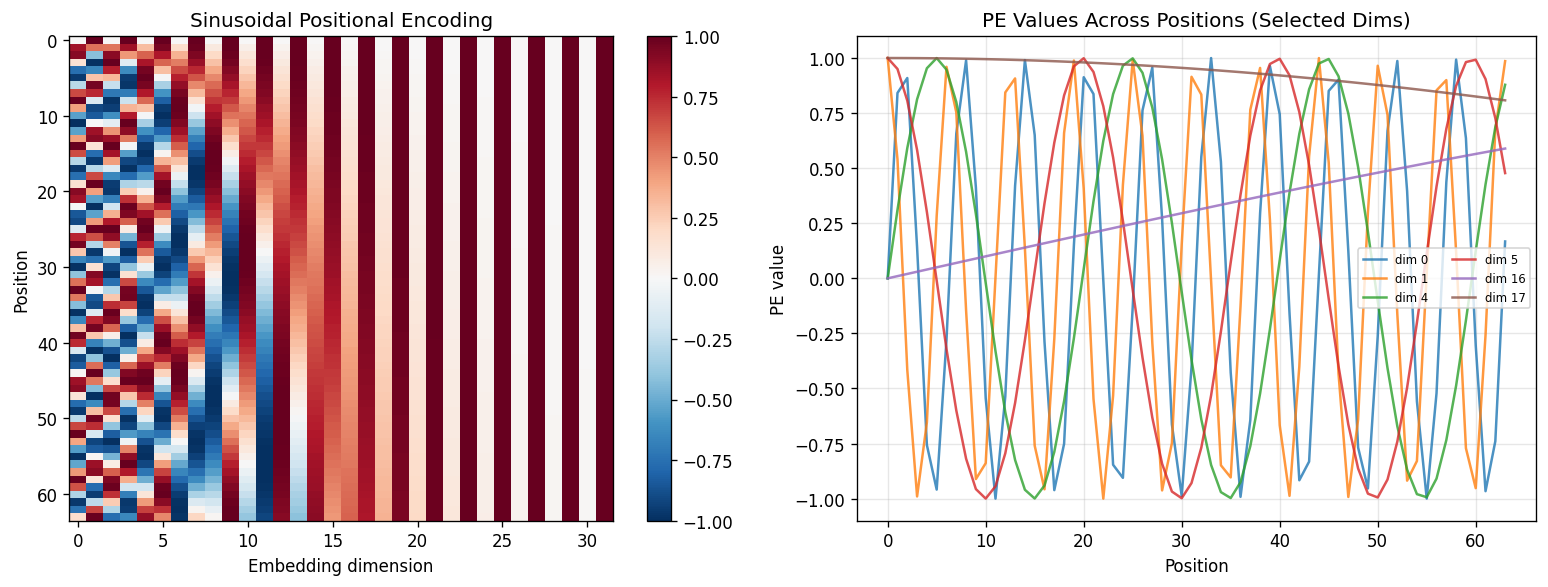

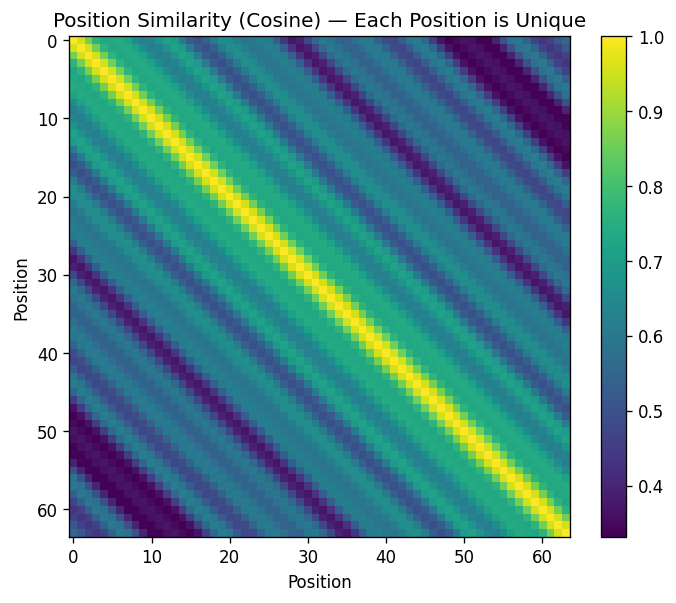


💡 Notice: nearby positions are more similar (bright diagonal band).
   This gives the model a smooth notion of 'closeness' in position.


Bad pipe message: %s [b'\xc8\xf2\xe7\x90\xf1\x91\x96\xfb\xc7\xed|6Cg<\x9cS\x94\x00\x01|\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\x05\x00\x06\x00\x07\x00\x08\x00\t\x00\n\x00\x0b\x00\x0c\x00\r\x00\x0e\x00\x0f\x00\x10\x00\x11\x00\x12\x00\x13\x00']
Bad pipe message: %s [b'\nK0\xd1\xf1\xfd"\xc2\x9f\x175\xe2o2\xb2\x1e\x8c\xad\x00\x01|\x00\x00\x00\x01\x00', b'\x03']
Bad pipe message: %s [b'\xa2\xd9&m\x8a>\xea\x01\xbe\x0c\xd2\x9bH\x18\xbd\xd6DT\x00\x01|\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\x05\x00\x06\x00\x07\x00\x08\x00\t\x00\n\x00\x0b\x00\x0c\x00\r\x00\x0e\x00\x0f\x00\x10\x00\x11\x00\x12\x00\x13\x00\x14\x00\x15\x00\x16\x00\x17\x00\x18\x00\x19\x00\x1a\x00\x1b\x00/\x000\x001\x002\x003\x004\x005\x006\x007\x008\x009\x00:\x00;\x00<\x00=\x00>\x00?\x00@\x00A\x00B\x00C\x00D\x00E\x00F\x00g\x00h\x00i\x00j\x00k\x00l\x00m\x00\x84\x00\x85\x00\x86\x00\x87\x00\x88\x00\x89\x00\x96\x00\x97\x00\x98\x00\x99\x00\x9a\x00\x9b\x00\x9c\x00\x9d\x00\x9e\x00\x9f\x00\xa0\x00\xa1\x00\xa2\x00\xa3\x00\xa4\x00\xa

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: full PE heatmap
pe_np = np.array(pe)
im0 = axes[0].imshow(pe_np, aspect='auto', cmap='RdBu_r')
axes[0].set_title('Sinusoidal Positional Encoding')
axes[0].set_xlabel('Embedding dimension')
axes[0].set_ylabel('Position')
plt.colorbar(im0, ax=axes[0])

# Right: individual dimension waves
for dim in [0, 1, 4, 5, 16, 17]:
    axes[1].plot(pe_np[:, dim], label=f'dim {dim}', alpha=0.8)
axes[1].set_title('PE Values Across Positions (Selected Dims)')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('PE value')
axes[1].legend(fontsize=7, ncol=2)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Show uniqueness: cosine similarity between position encodings
pe_norms = pe_np / np.linalg.norm(pe_np, axis=-1, keepdims=True)
pos_sim = pe_norms @ pe_norms.T  # shape: (64, 64)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(pos_sim, cmap='viridis')
ax.set_title('Position Similarity (Cosine) — Each Position is Unique')
ax.set_xlabel('Position')
ax.set_ylabel('Position')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print("\n💡 Notice: nearby positions are more similar (bright diagonal band).")
print("   This gives the model a smooth notion of 'closeness' in position.")

---
## Part 3: Rotary Position Embeddings (RoPE)

RoPE (Su et al., 2021) is the positional encoding used in **LLaMA, Gemma, Mistral, and most modern LLMs**. Instead of *adding* position info to embeddings, RoPE *rotates* them.

### The 2D Rotation Intuition

Think of each pair of embedding dimensions as a 2D point. RoPE rotates that point by an angle proportional to its position:

$$\begin{bmatrix} x'_0 \\ x'_1 \end{bmatrix} = \begin{bmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{bmatrix} \begin{bmatrix} x_0 \\ x_1 \end{bmatrix}$$

Where $\theta = pos \cdot \omega_i$ and $\omega_i = 1 / 10000^{2i/d}$.

The magic: when you compute `dot(RoPE(q, pos_m), RoPE(k, pos_n))`, the result depends only on the **relative distance** `m - n`, not the absolute positions. This is exactly what we want for attention!

💡 **Key insight**: Rotation preserves vector norms (`||RoPE(x)|| == ||x||`), so it doesn’t distort the embedding magnitudes — it only encodes position through the *angle*.

⚡ **Apple Silicon note**: RoPE is applied to Q and K *after* projection, not to the raw embeddings. This means it’s computed per-head, which parallelizes well on Metal.

### 🕐 The Clock Hand Analogy

Before we dive into code, here's the plain-English version:

**RoPE rotates vectors like a clock hand — the angle tells you the position.**

Imagine each pair of embedding dimensions as a clock face. At position 0, the hand points at 12 o'clock. At position 1, it rotates a little. At position 2, a little more. The key trick: different dimension pairs rotate at different speeds — some are "second hands" (fast), others are "hour hands" (slow). Together, they give every position a unique combination of angles, like a timestamp.

Why does this help attention? When two tokens compute their attention score (a dot product), the rotation angles *subtract*. So the score depends on how far apart the tokens are (relative position), not where they sit in the sequence (absolute position). Two tokens 5 apart always "see" the same angular difference, whether they're at positions 3 & 8 or 100 & 105.

That's the entire idea. Now let's build it step by step.

In [ ]:
# Step 1: Precompute rotation frequencies

def precompute_freqs_cis(d_head: int, max_seq_len: int, theta: float = 10000.0) -> tuple:
    """Precompute cos and sin for RoPE.
    
    Args:
        d_head: head dimension (must be even)
        max_seq_len: maximum sequence length
        theta: base frequency (10000 in original paper)
    
    Returns:
        cos_freqs: shape (max_seq_len, d_head//2)
        sin_freqs: shape (max_seq_len, d_head//2)
    """
    # Frequency for each pair of dimensions
    i = mx.arange(0, d_head, 2)  # shape: (d_head//2,)
    freqs = 1.0 / (theta ** (i / d_head))  # shape: (d_head//2,)
    
    # Outer product: position * frequency
    pos = mx.arange(max_seq_len)  # shape: (max_seq_len,)
    angles = pos.reshape(-1, 1) * freqs.reshape(1, -1)  # shape: (max_seq_len, d_head//2)
    
    cos_freqs = mx.cos(angles)  # shape: (max_seq_len, d_head//2)
    sin_freqs = mx.sin(angles)  # shape: (max_seq_len, d_head//2)
    
    mx.eval(cos_freqs, sin_freqs)
    return cos_freqs, sin_freqs

# Demo
d_head = 16
max_seq = 64
cos_f, sin_f = precompute_freqs_cis(d_head, max_seq)
print(f"cos_freqs shape: {cos_f.shape}")  # (64, 8)
print(f"sin_freqs shape: {sin_f.shape}")  # (64, 8)
print(f"\nFrequencies for d_head={d_head}:")
freqs = 1.0 / (10000.0 ** (mx.arange(0, d_head, 2) / d_head))
mx.eval(freqs)
print(f"  {freqs.tolist()}")
print(f"  Fastest (dim 0): completes full rotation every {2 * 3.14159 / freqs[0].item():.1f} positions")
print(f"  Slowest (dim {d_head-2}): completes full rotation every {2 * 3.14159 / freqs[-1].item():.1f} positions")

### Applying RoPE to Query/Key Vectors

RoPE rotates each consecutive pair of dimensions `(x_0, x_1)`, `(x_2, x_3)`, etc. by the position-dependent angle. This is applied to Q and K vectors *after* the linear projection.

⚠️ **Common pitfall**: RoPE is applied to Q and K only, **not** to V. Values carry content, not position.

In [ ]:
# Step 2: Apply RoPE rotation

def apply_rope(x: mx.array, cos_freqs: mx.array, sin_freqs: mx.array) -> mx.array:
    """Apply Rotary Position Embeddings.
    
    Args:
        x: shape (batch, seq_len, n_heads, d_head)
        cos_freqs: shape (seq_len, d_head//2)
        sin_freqs: shape (seq_len, d_head//2)
    
    Returns:
        shape (batch, seq_len, n_heads, d_head) — rotated tensor
    """
    seq_len = x.shape[1]
    d_head = x.shape[-1]
    
    # Reshape x into pairs: (..., d_head//2, 2)
    x_pairs = x.reshape(*x.shape[:-1], d_head // 2, 2)  # shape: (B, T, H, d_head//2, 2)
    x_0 = x_pairs[..., 0]  # shape: (B, T, H, d_head//2)
    x_1 = x_pairs[..., 1]  # shape: (B, T, H, d_head//2)
    
    # Slice frequencies to match sequence length and broadcast
    cos_f = cos_freqs[:seq_len].reshape(1, seq_len, 1, -1)  # shape: (1, T, 1, d_head//2)
    sin_f = sin_freqs[:seq_len].reshape(1, seq_len, 1, -1)  # shape: (1, T, 1, d_head//2)
    
    # Apply 2D rotation to each pair
    rotated_0 = x_0 * cos_f - x_1 * sin_f  # shape: (B, T, H, d_head//2)
    rotated_1 = x_0 * sin_f + x_1 * cos_f  # shape: (B, T, H, d_head//2)
    
    # Reassemble: stack pairs and reshape back
    rotated = mx.stack([rotated_0, rotated_1], axis=-1)  # shape: (B, T, H, d_head//2, 2)
    return rotated.reshape(x.shape)  # shape: (B, T, H, d_head)

# Demo: apply RoPE to a batch of Q vectors
batch, seq_len, n_heads, d_head = 2, 8, 4, 16
mx.random.seed(42)
q = mx.random.normal((batch, seq_len, n_heads, d_head))  # shape: (2, 8, 4, 16)

cos_f, sin_f = precompute_freqs_cis(d_head, seq_len)
q_rotated = apply_rope(q, cos_f, sin_f)  # shape: (2, 8, 4, 16)
mx.eval(q, q_rotated)

print(f"Input Q shape:  {q.shape}")
print(f"Output Q shape: {q_rotated.shape}")
print(f"\n✅ Shapes preserved — RoPE is a drop-in replacement.")

### Verifying Norm Preservation

A rotation matrix is orthogonal, so it preserves the L2 norm of every vector. Let’s verify: `||RoPE(x, pos)|| == ||x||` for all positions.

🎯 **Interview tip**: Norm preservation is why RoPE is preferred over additive PE in practice — it doesn’t change the scale of activations, which helps training stability.

In [ ]:
# Verify norm preservation: ||RoPE(x)|| == ||x||
norm_before = mx.sqrt(mx.sum(q * q, axis=-1))  # shape: (2, 8, 4)
norm_after = mx.sqrt(mx.sum(q_rotated * q_rotated, axis=-1))  # shape: (2, 8, 4)
mx.eval(norm_before, norm_after)

max_norm_diff = mx.abs(norm_before - norm_after).max().item()
mean_norm_diff = mx.mean(mx.abs(norm_before - norm_after)).item()

print("Norm Preservation Check:")
print(f"  Max  |norm_before - norm_after|: {max_norm_diff:.2e}")
print(f"  Mean |norm_before - norm_after|: {mean_norm_diff:.2e}")
print(f"  Preserved (within float tolerance)? {max_norm_diff < 1e-5}")

# Show a few examples
print(f"\nSample norms (batch=0, head=0):")
for pos in range(min(4, seq_len)):
    nb = norm_before[0, pos, 0].item()
    na = norm_after[0, pos, 0].item()
    print(f"  pos={pos}: before={nb:.6f}, after={na:.6f}, diff={abs(nb-na):.2e}")

print(f"\n✅ RoPE is a pure rotation — norms are perfectly preserved.")

### Visualizing RoPE Rotation

Let’s see how RoPE rotates embedding pairs in 2D space. Each pair of dimensions gets rotated by a position-dependent angle. Low-index pairs rotate fast, high-index pairs rotate slow.

In [ ]:
# Visualize RoPE rotation in 2D for a single vector across positions
d_head_viz = 8
max_pos = 32
cos_v, sin_v = precompute_freqs_cis(d_head_viz, max_pos)

# Fixed input vector (same at every position)
x_fixed = mx.ones((1, max_pos, 1, d_head_viz))  # shape: (1, 32, 1, 8)
x_rotated = apply_rope(x_fixed, cos_v, sin_v)  # shape: (1, 32, 1, 8)
mx.eval(x_rotated)

x_rot_np = np.array(x_rotated[0, :, 0, :])  # shape: (32, 8)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
pair_names = ['Pair 0 (dims 0,1)', 'Pair 1 (dims 2,3)', 'Pair 2 (dims 4,5)', 'Pair 3 (dims 6,7)']

for idx in range(4):
    ax = axes[idx]
    d0, d1 = idx * 2, idx * 2 + 1
    xs = x_rot_np[:, d0]
    ys = x_rot_np[:, d1]
    
    # Color by position
    colors = np.arange(max_pos)
    scatter = ax.scatter(xs, ys, c=colors, cmap='viridis', s=20, zorder=2)
    
    # Connect consecutive positions
    ax.plot(xs, ys, 'k-', alpha=0.2, linewidth=0.5)
    
    # Mark start and end
    ax.scatter([xs[0]], [ys[0]], c='red', s=60, marker='o', zorder=3, label='pos=0')
    ax.scatter([xs[-1]], [ys[-1]], c='blue', s=60, marker='s', zorder=3, label=f'pos={max_pos-1}')
    
    ax.set_title(pair_names[idx], fontsize=9)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=7)

plt.suptitle('RoPE: 2D Rotation of Dimension Pairs Across Positions', fontsize=11)
plt.tight_layout()
plt.show()

print("\n💡 Pair 0 (low dims) rotates fast — completes many cycles.")
print("   Pair 3 (high dims) rotates slow — barely moves.")
print("   This multi-frequency structure gives each position a unique encoding.")

---
## Part 4: Comparison — Sinusoidal vs RoPE vs Learned Embeddings

| Property | Sinusoidal (2017) | Learned Embeddings | RoPE (2021) |
|---|---|---|---|
| **How it works** | Add fixed sin/cos to embeddings | Add learned vectors (one per position) | Rotate Q, K by position-dependent angle |
| **Parameters** | 0 (fixed) | `max_seq_len × d_model` | 0 (fixed) |
| **Position type** | Absolute | Absolute | **Relative** (via rotation) |
| **Extrapolation** | Moderate (smooth waves) | ❌ None (unseen positions = random) | ✅ Good (rotation generalizes) |
| **Applied to** | Embeddings (before attention) | Embeddings (before attention) | Q and K only (inside attention) |
| **Norm preservation** | ❌ No (addition changes norm) | ❌ No (addition changes norm) | ✅ Yes (rotation is orthogonal) |
| **Used in** | Original Transformer, BERT | GPT-2, early GPT-3 | **LLaMA, Gemma, Mistral, Qwen, Phi** |

### Why RoPE Wins for Modern LLMs

💡 **Relative position**: Attention scores `qᵀk` naturally encode the *distance* between tokens, not their absolute positions. This is more linguistically meaningful — "the word 3 tokens ago" matters more than "the word at position 47."

⚡ **Length extrapolation**: RoPE can handle sequences longer than training length because rotation angles are continuous. Combined with techniques like NTK-aware scaling and YaRN, RoPE-based models can extend from 4K to 128K+ context.

🎯 **Interview tip**: If asked "why not just learn position embeddings?" — learned embeddings can’t generalize beyond `max_seq_len` seen during training, and they add parameters. RoPE is parameter-free, norm-preserving, and encodes relative position — three wins in one.

In [ ]:
# Quick comparison: parameter counts
vocab_size = 32000  # typical LLM vocab
d_model = 4096      # typical LLM hidden size
max_seq = 8192      # typical context length

learned_params = max_seq * d_model
sinusoidal_params = 0
rope_params = 0

print("Positional Encoding Parameter Comparison")
print("=" * 50)
print(f"Model config: d_model={d_model}, max_seq={max_seq}")
print(f"")
print(f"  Sinusoidal:  {sinusoidal_params:>12,} params (fixed, no learning)")
print(f"  RoPE:        {rope_params:>12,} params (fixed, no learning)")
print(f"  Learned:     {learned_params:>12,} params ({learned_params * 2 / 1e6:.1f} MB in float16)")
print(f"")
print(f"💡 For a 7B parameter model, learned PE adds {learned_params/7e9*100:.2f}% overhead.")
print(f"   Not huge, but RoPE gives better extrapolation for free.")
print()
print("Modern LLM Positional Encoding Choices:")
print("-" * 50)
for name, pe_type in [
    ("GPT-2 / GPT-3", "Learned absolute"),
    ("Original Transformer", "Sinusoidal"),
    ("LLaMA 1/2/3", "RoPE"),
    ("Gemma 1/2", "RoPE"),
    ("Mistral / Mixtral", "RoPE"),
    ("Qwen 2.5", "RoPE"),
    ("Phi-3", "RoPE"),
]:
    print(f"  {name:<25} → {pe_type}")

---
## Summary & Key Takeaways

**What we built in this notebook:**
1. **Token embeddings** — a lookup table mapping token IDs to dense vectors (`nn.Embedding`)
2. **Sinusoidal PE** — fixed sin/cos waves that give each position a unique fingerprint
3. **RoPE** — rotation-based encoding that preserves norms and encodes relative position

**Key mental models:**
- 💡 Transformers are permutation-invariant — position must be explicitly injected
- 💡 RoPE encodes position through *rotation*, not addition — this preserves norms and enables relative position attention
- ⚡ RoPE is parameter-free and applied only to Q, K — not V
- 🎯 Modern LLMs (LLaMA, Gemma, Mistral) all use RoPE because it extrapolates to longer sequences
- ⚠️ Learned position embeddings can't generalize beyond training length

**Next up:** [Notebook 05: Self-Attention from Scratch](05_self_attention.ipynb) — where we use these embeddings as input to the attention mechanism.

## 📜 History & Alternatives

### The Evolution of Positional Encoding

Transformers have no inherent notion of token order — positional encodings inject sequence position information. The field evolved from fixed mathematical functions to learned and relative schemes that enable length generalization.

| Year | Method | Team | Key Contribution |
|------|--------|------|-----------------|
| 2017 | **Sinusoidal PE** | Vaswani et al. (Google) | Fixed sin/cos functions at different frequencies — original Transformer |
| 2017 | **Learned PE** | Vaswani et al. (Google) | Trainable position embeddings — used in GPT-1, BERT |
| 2018 | **Relative PE** | Shaw et al. (Google) | Encode relative distance between tokens, not absolute position |
| 2021 | **Rotary PE (RoPE)** | Su et al. (Zhuiyi Tech) | Rotate Q/K vectors by position-dependent angles — encodes relative position through dot products |
| 2021 | **ALiBi** | Press et al. (Meta) | No positional embedding — add linear bias to attention scores based on distance |
| 2022 | **xPos** | Sun et al. | Extended RoPE with exponential decay for better length extrapolation |
| 2023 | **YaRN** | Peng et al. | RoPE scaling via NTK-aware interpolation — extends context without fine-tuning |
| 2023 | **LongRoPE** | Microsoft | Progressive interpolation for 2M+ context lengths |
| 2024 | **p-RoPE (partial RoPE)** | Google DeepMind (Gemma 2/3) | Apply RoPE to only a fraction of head dimensions — rest are position-free |

### 💡 Why RoPE Won

RoPE became the dominant positional encoding (used in LLaMA, Mistral, Gemma, Qwen, and most modern LLMs) because of three properties:

1. **Relative position via dot product**: `⟨RoPE(q, m), RoPE(k, n)⟩` depends only on `m - n`, not absolute positions
2. **Decaying with distance**: Attention naturally decreases for distant tokens (desirable inductive bias)
3. **Length extrapolation**: With interpolation tricks (YaRN, NTK-aware), RoPE models can generalize to longer sequences than seen during training

### Positional Encoding Comparison

| Method | Type | Length Generalization | Used By | Complexity |
|--------|------|---------------------|---------|------------|
| Sinusoidal | Absolute, fixed | Poor beyond training length | Original Transformer | O(1) per position |
| Learned | Absolute, trained | Poor — hard limit at max position | GPT-2, BERT | O(1) per position |
| RoPE | Relative, fixed | Good with interpolation | LLaMA, Mistral, Qwen | O(d) rotation per head |
| ALiBi | Relative, fixed | Excellent — no position limit | BLOOM, MPT | O(1) bias per attention pair |
| p-RoPE | Partial relative | Excellent | Gemma 2, Gemma 3, Gemma 4 | O(d/2) rotation on subset |

### ⚡ The Context Length Revolution

The evolution of positional encodings directly enabled the context length explosion:
- 2017: 512 tokens (original Transformer)
- 2020: 2,048 tokens (GPT-3)
- 2023: 8,192 → 32,768 tokens (LLaMA 2 → Mistral)
- 2024: 128K → 1M tokens (GPT-4 Turbo → Gemini 1.5)
- 2025: 2M+ tokens (Gemini 2.5)

Each jump required better positional encodings (RoPE interpolation, ALiBi) combined with efficient attention (Flash Attention, Ring Attention).

### ⚠️ Common Pitfalls

1. **Forgetting to scale RoPE frequencies when extending context**: Naively using a model beyond its trained context length causes catastrophic attention score degradation. You must apply NTK-aware interpolation or YaRN scaling — never just increase `max_seq_len` without adjusting the frequency base.
2. **Mixing absolute and relative PE assumptions**: Some architectures (e.g., BERT) bake absolute position IDs into the model. Switching to RoPE requires removing the old position embeddings entirely, not layering them.
3. **Ignoring the base frequency (`theta`)**: RoPE's `theta` parameter (default 10,000) controls the wavelength spectrum. Models trained with one `theta` value perform poorly if you change it at inference without retraining or careful interpolation.

### 🎯 Interview Tip

> *"RoPE encodes position by rotating query and key vectors in 2D subspaces — the rotation angle is proportional to position × frequency. When you compute the dot product Q·K, the rotation angles subtract, making the result depend only on relative position (m-n). This is mathematically elegant because it achieves relative positional encoding without modifying the attention mechanism itself — you just rotate the inputs. The partial-RoPE variant in Gemma applies rotation to only some head dimensions, leaving others position-free to capture global (position-independent) patterns."*